In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for parent in [current] + list(current.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        SRC_PATH = parent / "src"
        break
else:
    raise FileNotFoundError("Cannot find project root with src folder.")


for path in [PROJECT_ROOT, SRC_PATH]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("Project root:", PROJECT_ROOT)
print("Src path:", SRC_PATH)

import config
import transforms

print("config imported from:", config.__file__)
print("transforms imported from:", transforms.__file__)




Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
Src path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src
config imported from: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src\config.py
transforms imported from: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src\transforms.py


In [3]:
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from src.config import (
    DEVICE,
    NUM_EPOCHS,
    RANDOM_SEED,
    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    CLASS_NAMES,
)

from src.dataset import get_dataloaders
from src.metrics import calculate_classification_metrics
from src.transfer_models_DenseNet.densenet121_model import get_densenet121

MODEL_NAME = "densenet121"
LEARNING_RATE = 0.0001
PATIENCE = 5

print("Device from config:", DEVICE)
print("Number of epochs:", NUM_EPOCHS)
print("Classes:", CLASS_NAMES)




Device from config: cuda
Number of epochs: 20
Classes: ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(DEVICE)

print("Using device:", device)




Using device: cuda


In [5]:
train_loader, val_loader, test_loader = get_dataloaders()

print("DataLoader info:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")




DataLoader info:
Train batches: 64
Validation batches: 10
Test batches: 19


rennet model

In [6]:
train_loader, val_loader, test_loader = get_dataloaders()

print("DataLoader info:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")




DataLoader info:
Train batches: 64
Validation batches: 10
Test batches: 19


improve densenet + ordinal aware loss

In [7]:
# Improved DenseNet121 + Ordinal-aware Loss

from torchvision import models
import torch.nn.functional as F

MODEL_VERSION = "improved_densenet121_ordinal_loss"

NUM_CLASSES = len(CLASS_NAMES)

ORDINAL_ALPHA = 0.3

STAGE_1_EPOCHS = 5
STAGE_2_EPOCHS = 15

STAGE_1_LR = 1e-4
STAGE_2_LR = 1e-5

WEIGHT_DECAY = 1e-4
PATIENCE = 5
DROPOUT = 0.3
HIDDEN_FEATURES = 512


def get_densenet121_improved(
    num_classes=5,
    pretrained=True,
    dropout=0.3,
    hidden_features=512
):
    """
    Improved DenseNet121:
    - Pretrained DenseNet121 backbone
    - Dropout-based classifier head
    """

    try:
        from torchvision.models import DenseNet121_Weights
        weights = DenseNet121_Weights.DEFAULT if pretrained else None
        model = models.densenet121(weights=weights)
    except Exception:
        model = models.densenet121(pretrained=pretrained)

    in_features = model.classifier.in_features

    # Improved classifier head
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, hidden_features),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_features, num_classes)
    )

    return model


def set_trainable_stage(model, stage="head"):
    """
    stage='head':
        only train classifier head

    stage='last_block':
        train classifier head + denseblock4 + norm5
    """

    # Freeze everything first
    for param in model.parameters():
        param.requires_grad = False

    # Always train classifier head
    for param in model.classifier.parameters():
        param.requires_grad = True

    if stage == "last_block":
        for param in model.features.denseblock4.parameters():
            param.requires_grad = True

        for param in model.features.norm5.parameters():
            param.requires_grad = True

    return model


class OrdinalAwareLoss(nn.Module):
    """
    Ordinal-aware loss for KL grade classification.

    Loss = CrossEntropyLoss + alpha * ordinal distance penalty

    It encourages the model to avoid distant-grade errors.
    """

    def __init__(self, num_classes=5, alpha=0.3):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha

    def forward(self, logits, targets):
        # Standard classification loss
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none"
        )

        # Convert logits to probabilities
        probs = F.softmax(logits, dim=1)

        # Class indices: [0, 1, 2, 3, 4]
        class_indices = torch.arange(
            self.num_classes,
            device=logits.device,
            dtype=torch.float32
        )

        # Expected predicted KL grade
        expected_grade = torch.sum(probs * class_indices, dim=1)

        # Ordinal distance penalty
        ordinal_penalty = torch.abs(expected_grade - targets.float())

        loss = ce_loss + self.alpha * ordinal_penalty

        return loss.mean()


def count_trainable_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return trainable_params, total_params


model = get_densenet121_improved(
    num_classes=NUM_CLASSES,
    pretrained=True,
    dropout=DROPOUT,
    hidden_features=HIDDEN_FEATURES
).to(device)

criterion = OrdinalAwareLoss(
    num_classes=NUM_CLASSES,
    alpha=ORDINAL_ALPHA
).to(device)

print("=" * 60)
print("Improved DenseNet121 + Ordinal-aware Loss")
print("=" * 60)
print(f"Model version: {MODEL_VERSION}")
print(f"Ordinal alpha: {ORDINAL_ALPHA}")
print(f"Dropout: {DROPOUT}")
print(f"Hidden features: {HIDDEN_FEATURES}")
print(f"Stage 1 epochs: {STAGE_1_EPOCHS}, lr: {STAGE_1_LR}")
print(f"Stage 2 epochs: {STAGE_2_EPOCHS}, lr: {STAGE_2_LR}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Patience: {PATIENCE}")




Improved DenseNet121 + Ordinal-aware Loss
Model version: improved_densenet121_ordinal_loss
Ordinal alpha: 0.3
Dropout: 0.3
Hidden features: 512
Stage 1 epochs: 5, lr: 0.0001
Stage 2 epochs: 15, lr: 1e-05
Weight decay: 0.0001
Patience: 5


In [8]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate_one_epoch(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc




Stage 1：only classifier head  
Stage 2：refreeze denseblock4 + norm5，use learning rate fine tuning   

In [10]:
best_model_path = MODEL_DIR / f"{MODEL_VERSION}_best.pth"
history_path = RESULT_DIR / f"{MODEL_VERSION}_training_history.csv"

history = {
    "global_epoch": [],
    "stage": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "learning_rate": [],
}

best_val_loss = float("inf")
best_val_acc = 0.0
global_epoch = 0

start_time = time.time()


def run_training_stage(
    model,
    stage_name,
    num_epochs,
    learning_rate,
    best_val_loss,
    best_val_acc,
    global_epoch
):
    print("\n" + "=" * 60)
    print(f"Training Stage: {stage_name}")
    print("=" * 60)

    trainable_params, total_params = count_trainable_parameters(model)

    print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")
    print(f"Learning rate: {learning_rate}")

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    epochs_without_improvement = 0

    for local_epoch in range(1, num_epochs + 1):
        global_epoch += 1

        train_loss, train_acc = train_one_epoch(
            model=model,
            train_loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        val_loss, val_acc = evaluate_one_epoch(
            model=model,
            data_loader=val_loader,
            criterion=criterion,
            device=device
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["global_epoch"].append(global_epoch)
        history["stage"].append(stage_name)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["learning_rate"].append(current_lr)

        print(
            f"Epoch [{local_epoch}/{num_epochs}] "
            f"Global Epoch [{global_epoch}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"LR: {current_lr:.8f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_without_improvement = 0

            torch.save(model.state_dict(), best_model_path)
            print(f"Best model saved: {best_model_path}")
        else:
            epochs_without_improvement += 1
            print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

        scheduler.step(val_loss)

        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping triggered in {stage_name}.")
            break

    return best_val_loss, best_val_acc, global_epoch


# ==============================
# Stage 1: Train classifier head only
# ==============================

model = set_trainable_stage(model, stage="head")

best_val_loss, best_val_acc, global_epoch = run_training_stage(
    model=model,
    stage_name="Stage 1 - classifier head only",
    num_epochs=STAGE_1_EPOCHS,
    learning_rate=STAGE_1_LR,
    best_val_loss=best_val_loss,
    best_val_acc=best_val_acc,
    global_epoch=global_epoch
)


# ==============================
# Stage 2: Fine-tune last DenseNet block
# ==============================

model = set_trainable_stage(model, stage="last_block")

best_val_loss, best_val_acc, global_epoch = run_training_stage(
    model=model,
    stage_name="Stage 2 - fine-tune denseblock4",
    num_epochs=STAGE_2_EPOCHS,
    learning_rate=STAGE_2_LR,
    best_val_loss=best_val_loss,
    best_val_acc=best_val_acc,
    global_epoch=global_epoch
)


end_time = time.time()
training_time = end_time - start_time

history_df = pd.DataFrame(history)
history_df.to_csv(history_path, index=False)

print("\n" + "=" * 60)
print("Improved DenseNet121 training finished")
print("=" * 60)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Total epochs trained: {len(history['global_epoch'])}")
print(f"Training time: {training_time:.2f} seconds")
print(f"History saved to: {history_path}")
print(f"Best model saved to: {best_model_path}")





Training Stage: Stage 1 - classifier head only
Trainable parameters: 527,365 / 7,481,221
Learning rate: 0.0001
Epoch [1/5] Global Epoch [1] | Train Loss: 1.8657 | Train Acc: 0.3174 | Val Loss: 1.7720 | Val Acc: 0.3356 | LR: 0.00010000
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\improved_densenet121_ordinal_loss_best.pth
Epoch [2/5] Global Epoch [2] | Train Loss: 1.7583 | Train Acc: 0.3887 | Val Loss: 1.6297 | Val Acc: 0.4247 | LR: 0.00010000
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\improved_densenet121_ordinal_loss_best.pth
Epoch [3/5] Global Epoch [3] | Train Loss: 1.6444 | Train Acc: 0.4365 | Val Loss: 1.5277 | Val Acc: 0.4589 | LR: 0.00010000
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\improved_densenet121_ordinal_loss_best.pth
Epoch [4/5] Global Epoch [4] | Train Loss: 1.6019 | Train Acc: 0.4307 | Val Loss: 1.4657 | Val Acc: 0.5000 | LR: 0.00010000
Best model 

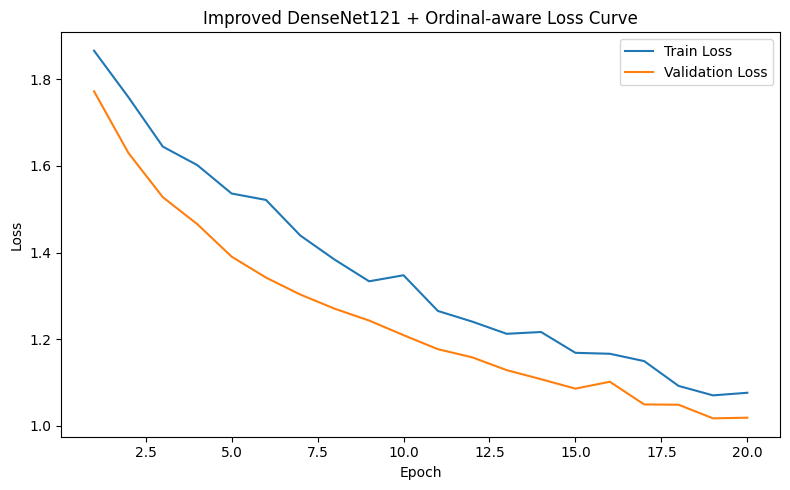

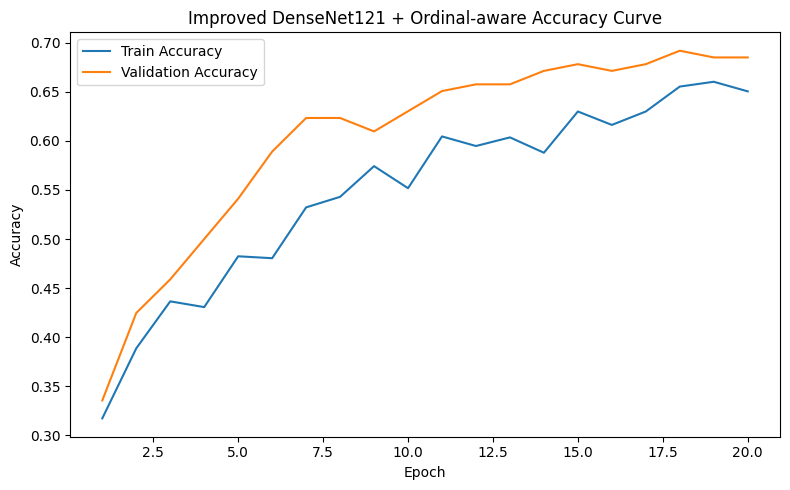

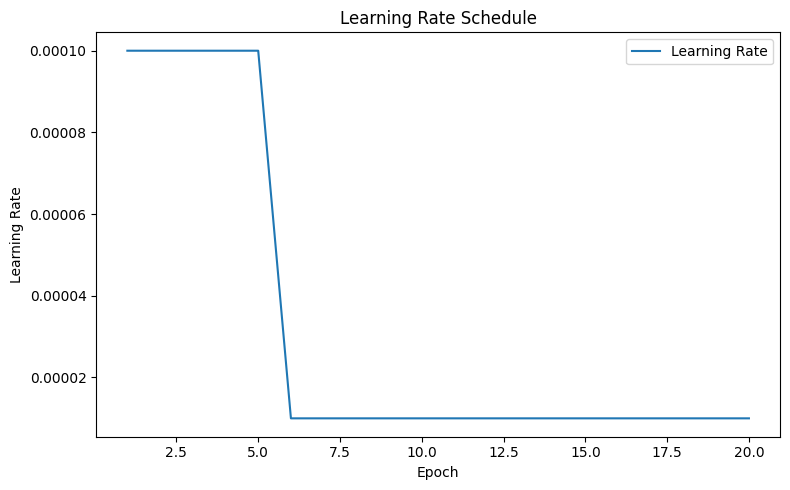

In [11]:
epochs = history["global_epoch"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved DenseNet121 + Ordinal-aware Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved DenseNet121 + Ordinal-aware Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["learning_rate"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")
plt.legend()
plt.tight_layout()
plt.show()




Evaluating Improved DenseNet121 + Ordinal-aware Loss on Test Set


C:\Users\Lv043\AppData\Local\Temp\ipykernel_22872\1706392865.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model.load_state_dict(torch.load(model_path, map_locat


Overall Test Metrics:
accuracy: 0.6735
macro_f1: 0.6252
weighted_f1: 0.6515
mae: 0.4558
qwk: 0.8027
total_errors: 96
adjacent_errors: 70
distant_errors: 26
adjacent_error_rate_among_errors: 0.7292
distant_error_rate_among_errors: 0.2708

Per-Class Metrics:


,label,class_name,precision,recall,f1_score,support
0,0,Normal,0.695238,0.802198,0.744898,91
1,1,Doubtful,0.612245,0.681818,0.645161,88
2,2,Mild,0.384615,0.131579,0.196078,38
3,3,Moderate,0.757576,0.714286,0.735294,35
4,4,Severe,0.777778,0.833333,0.804598,42


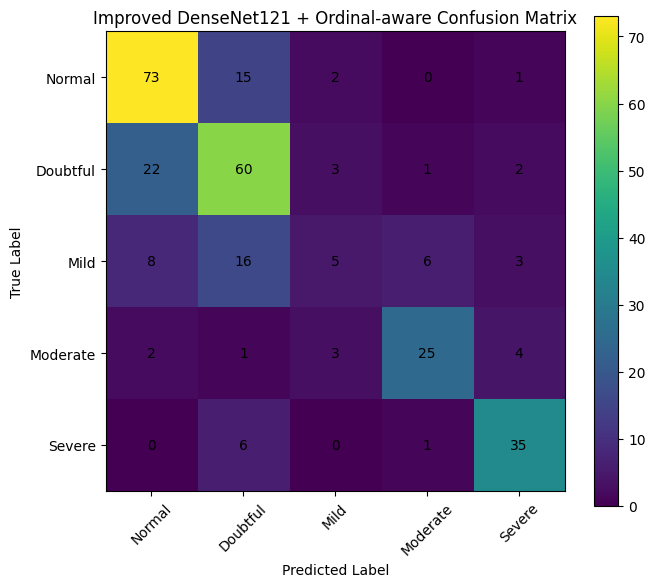

In [12]:
def predict(model, data_loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    softmax = torch.nn.Softmax(dim=1)

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            outputs = model(images)
            probs = softmax(outputs)
            _, preds = torch.max(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return all_labels, all_preds, all_probs


print("=" * 60)
print("Evaluating Improved DenseNet121 + Ordinal-aware Loss on Test Set")
print("=" * 60)

model_path = MODEL_DIR / f"{MODEL_VERSION}_best.pth"

if not model_path.exists():
    raise FileNotFoundError(
        f"Cannot find model file: {model_path}. Please run training first."
    )

test_model = get_densenet121_improved(
    num_classes=NUM_CLASSES,
    pretrained=False,
    dropout=DROPOUT,
    hidden_features=HIDDEN_FEATURES
).to(device)

test_model.load_state_dict(torch.load(model_path, map_location=device))

y_true, y_pred, y_probs = predict(
    model=test_model,
    data_loader=test_loader,
    device=device
)

overall_metrics, per_class_metrics, cm = calculate_classification_metrics(
    y_true=y_true,
    y_pred=y_pred,
    class_names=CLASS_NAMES
)

print("\nOverall Test Metrics:")
for key, value in overall_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nPer-Class Metrics:")
per_class_df = pd.DataFrame(per_class_metrics)
display(per_class_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Improved DenseNet121 + Ordinal-aware Confusion Matrix")
plt.colorbar()

tick_marks = range(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            verticalalignment="center"
        )

plt.tight_layout()
plt.show()


